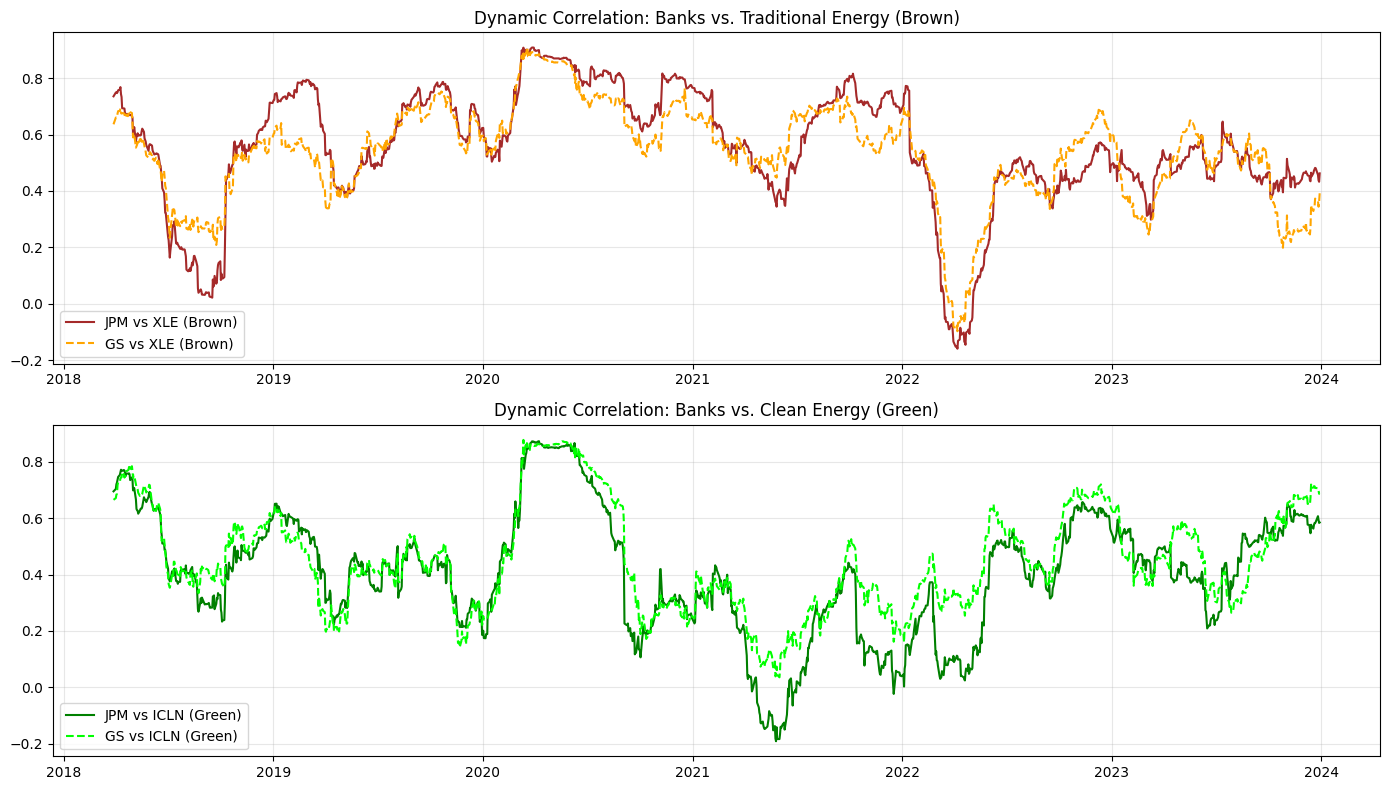


--- ESG Sensitivity Classification ---
Banks with higher 'Brown Beta' are more vulnerable to stranded asset shocks.
        Brown_Beta (XLE)  Green_Beta (ICLN)  Transition_Ratio
Ticker                                                       
C               0.746436           0.638016          1.169932
BCS             0.672726           0.615635          1.092736
BAC             0.660322           0.565020          1.168669
MS              0.635940           0.624453          1.018394
DB              0.613229           0.575677          1.065231
JPM             0.584035           0.496180          1.177063
GS              0.578457           0.565249          1.023367


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load Returns Data
try:
    path = os.path.join("..", "..", "data", "processed", "market_returns.csv")
    returns_df = pd.read_csv(path, index_col=0, parse_dates=True)
except FileNotFoundError:
    path = r"c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Risk Management & Sustainability (ESG)\Quantifying Systemic Risk in Central Clearing Counterparties (CCPs)\data\processed\market_returns.csv"
    returns_df = pd.read_csv(path, index_col=0, parse_dates=True)

cm_tickers = ['JPM', 'GS', 'MS', 'BAC', 'C', 'DB', 'BCS']

# 2. Compute Rolling Correlations (Dynamic Linkages)
# We use a 60-day window to capture medium-term structural shifts
window = 60
rolling_corr_brown = returns_df[cm_tickers].rolling(window).corr(returns_df['XLE'])
rolling_corr_green = returns_df[cm_tickers].rolling(window).corr(returns_df['ICLN'])

# 3. Visualization: The "Transition Risk" Split
plt.figure(figsize=(14, 8))

# Plot 1: Correlation with Brown Energy (Oil/Gas)
plt.subplot(2, 1, 1)
plt.plot(rolling_corr_brown.index, rolling_corr_brown['JPM'], label='JPM vs XLE (Brown)', color='brown')
plt.plot(rolling_corr_brown.index, rolling_corr_brown['GS'], label='GS vs XLE (Brown)', color='orange', linestyle='--')
plt.title("Dynamic Correlation: Banks vs. Traditional Energy (Brown)")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

# Plot 2: Correlation with Clean Energy
plt.subplot(2, 1, 2)
plt.plot(rolling_corr_green.index, rolling_corr_green['JPM'], label='JPM vs ICLN (Green)', color='green')
plt.plot(rolling_corr_green.index, rolling_corr_green['GS'], label='GS vs ICLN (Green)', color='lime', linestyle='--')
plt.title("Dynamic Correlation: Banks vs. Clean Energy (Green)")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Quantitative Classification: The "ESG Beta"
# We calculate the sensitivity of each bank to XLE vs ICLN over the whole period
# Beta = Covariance(Asset, Market) / Var(Market)

esg_sensitivity = []

for bank in cm_tickers:
    # Brown Beta
    cov_brown = np.cov(returns_df[bank], returns_df['XLE'])[0][1]
    var_brown = np.var(returns_df['XLE'])
    beta_brown = cov_brown / var_brown
    
    # Green Beta
    cov_green = np.cov(returns_df[bank], returns_df['ICLN'])[0][1]
    var_green = np.var(returns_df['ICLN'])
    beta_green = cov_green / var_green
    
    esg_sensitivity.append({
        'Ticker': bank,
        'Brown_Beta (XLE)': beta_brown,
        'Green_Beta (ICLN)': beta_green,
        'Transition_Ratio': beta_brown / beta_green # Higher ratio = More "Brown" Risk
    })

esg_df = pd.DataFrame(esg_sensitivity).set_index('Ticker').sort_values('Brown_Beta (XLE)', ascending=False)

print("\n--- ESG Sensitivity Classification ---")
print("Banks with higher 'Brown Beta' are more vulnerable to stranded asset shocks.")
print(esg_df)

# 5. Save Classification
output_path = os.path.join("..", "..", "data", "processed", "esg_sensitivity.csv")
esg_df.to_csv(output_path)